## 🍱 Mixed turbine power

**Concepts:** [Power in the Advanced API](../reference/power.md#advanced-api) · **Network/Router API:** [Mixed turbine power](hi16_mixed_power.ipynb)

The Advanced API declares nominal turbine power on a location graph **L** and carries it to the available-links graph **A**. Each producer quantizes these powers for its nominal capacity on a separate solve graph. This notebook follows the declaration and the resulting integer loads through **L → (P, A) → (S, G)**, then compares exact and inexact quantization.

In [1]:
from fractions import Fraction
from math import ceil

from prettyTables import Table

from optiwindnet.converting import G_from_S, terse_links_from_S
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import assign_cables
from optiwindnet.loads import (
    calcload,
    quantize_for_capacity,
    quantized,
    set_turbine_powers,
    terminal_inflow,
    total_inflow,
)
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.svg import svgplot

### Graph attributes and defaults

| Attribute | Meaning |
| --- | --- |
| Terminal `power` | Declared nominal power as a `Fraction`, present for unequal ratings. |
| Graph `powers_set` | Sorted tuple of distinct nominal ratings for unequal-power declarations. |
| Graph `power_unit` | Optional physical unit, such as `'MW'`. |
| Terminal `inflow` | Positive integer injection on a solve graph or topology; absent means **1**. |
| Graph `power_per_inflow` | Exact nominal power per inflow on a solution, or the common rating for equal-power declarations. |
| Node/edge `load`, graph `capacity` | Integer inflow used for routing and capacity checks. |
| Graph `capacity_nominal`, `power_rtol` | Nominal routing budget and quantization tolerance recorded on the solution. |

Terminals are `0 … T - 1`; substations are `-R … -1`. A graph with no power metadata keeps the uniform unit-injection interpretation. Explicit integer demands can instead be given as terminal `inflow`, with an integer solver `capacity`.

[set_turbine_powers()](../autoapi/optiwindnet/loads/index.rst#optiwindnet.loads.set_turbine_powers) replaces previous power attributes and validates the declaration. Equal ratings become only `power_per_inflow`; unequal ratings become `powers_set` and terminal `power`, without quantized inflows on **L** or **A**. [validate_terminal_power()](../autoapi/optiwindnet/loads/index.rst#optiwindnet.loads.validate_terminal_power) checks these conventions at graph-input boundaries; it does not choose a quantization.

### An illustrative change to Albatros

Copy the bundled location so its original ratings remain intact. Use its geometry for a hypothetical site with twelve 4 MW turbines and four 8 MW turbines. These are teaching inputs, not the actual Albatros ratings.

Declare the ratings through [set_turbine_powers()](../autoapi/optiwindnet/loads/index.rst#optiwindnet.loads.set_turbine_powers). The solver will choose an exact unit of 4 MW for a 20 MW cable, giving each turbine one or two inflow. That conversion is a property of the solve, not an input stored on this location.

In [2]:
locations = load_repository()
L = locations.albatros.copy()
L.graph['name'] = 'Albatros geometry: illustrative 4 and 8 MW turbines'
large_turbines = {0, 5, 10, 15}
powers_MW = [8 if t in large_turbines else 4 for t in range(L.graph['T'])]
set_turbine_powers(L, powers_MW, power_unit='MW')

In [3]:
assert L.graph['powers_set'] == (Fraction(4), Fraction(8))
assert 'power_per_inflow' not in L.graph
assert all('inflow' not in L.nodes[t] for t in range(L.graph['T']))
{
    'distinct_ratings_MW': L.graph['powers_set'],
    'turbines': L.graph['T'],
    'total_declared_MW': sum(powers_MW),
}

{'distinct_ratings_MW': (Fraction(4, 1), Fraction(8, 1)),
 'turbines': 16,
 'total_declared_MW': 80}

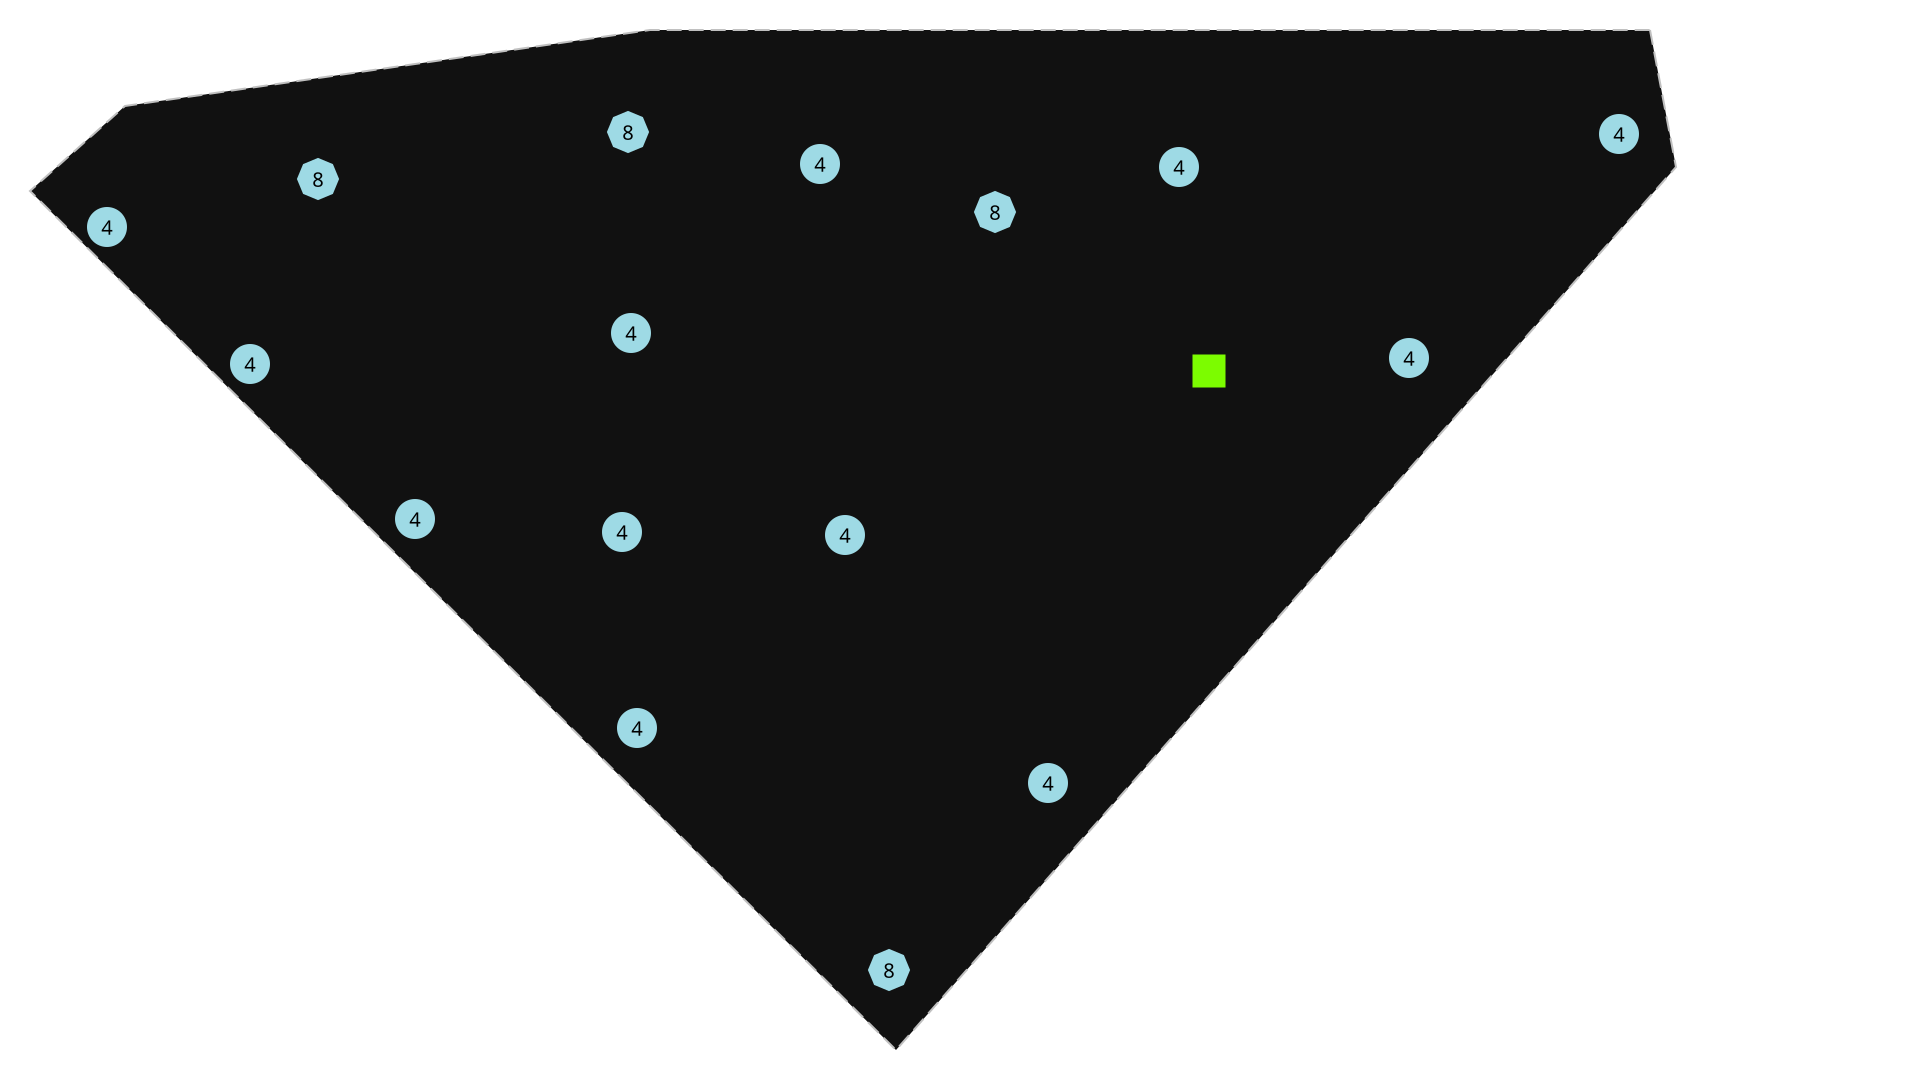

In [4]:
svgplot(L, node_tag='power')

### Build the mesh and solve

[make_planar_embedding()](../autoapi/optiwindnet/mesh/index.rst#optiwindnet.mesh.make_planar_embedding) propagates the declaration to **A**. Pass `capacity_nominal=20` and `power_rtol=0` to the solver, which quantizes a copy of **A**. `set_problem()` requires keyword arguments after **P** and **A**. Exactly one of `capacity` (integer inflow) and `capacity_nominal` is supplied; unequal-power declarations require the latter.

Here five inflow represent 20 MW. A feeder can carry five small turbines, two large turbines plus one small turbine, or another combination whose inflows sum to at most five. The 80 MW total implies a lower bound of four feeders. Such a bound need not be attainable for arbitrary mixed ratings, because turbines cannot be split across feeders. Leave `feeder_limit='unlimited'` so the solver can choose a feasible feeder count and use more feeders if that improves the objective.

The OR-Tools backend returns a computational topology **S** and a routed graph **G**; `get_solution()` handles topology conversion and detours.

In [5]:
P, A = make_planar_embedding(L)
assert A.graph['powers_set'] == L.graph['powers_set']
assert all('inflow' not in A.nodes[t] for t in range(A.graph['T']))

In [6]:
model_options = ModelOptions(
    topology='branched', feeder_route='segmented', feeder_limit='unlimited'
)
solver = solver_factory('ortools.cp_sat')
solver.set_problem(P, A, model_options=model_options, capacity_nominal=20, power_rtol=0)
solver.solve(time_limit=30, mip_gap=0.01, options={'random_seed': 1234567})
S, G = solver.get_solution()

In [7]:
capacity = S.graph['capacity']
assert capacity == 5
assert total_inflow(S) == 20
assert 'power_per_inflow' not in A.graph
{
    'MW_per_inflow': S.graph['power_per_inflow'],
    'terminal_inflows': terminal_inflow(S),
    'feeder_lower_bound': ceil(total_inflow(S) / capacity),
}

{'MW_per_inflow': Fraction(4, 1),
 'terminal_inflows': {0: 2, 5: 2, 10: 2, 15: 2},
 'feeder_lower_bound': 4}

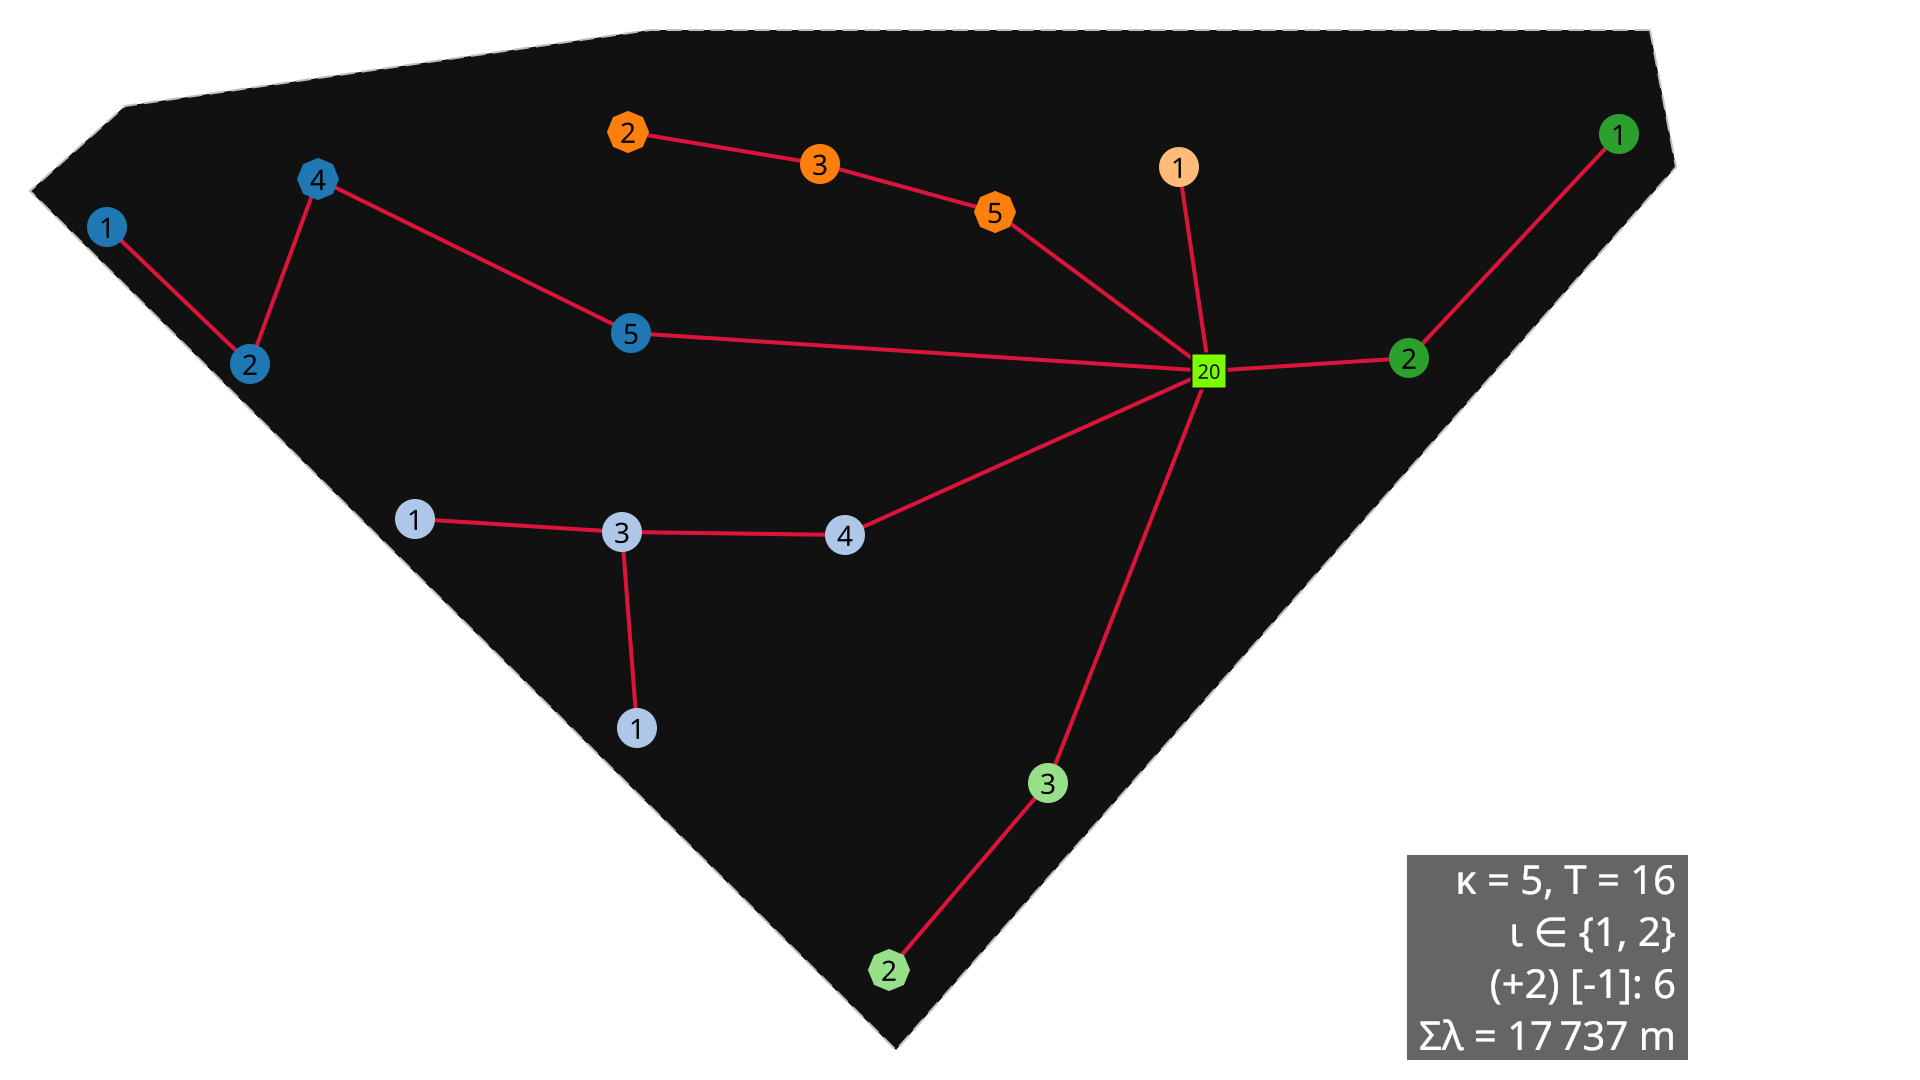

In [8]:
svgplot(G, node_tag='load')

### Check loads in the solver's units

Topology **S** retains integer inflows and the quantization attributes `power_per_inflow`, `capacity_nominal` and `power_rtol`, but omits declared terminal `power`, `powers_set` and `power_unit`. `calcload(S)` can recompute routing loads without the site.

For nominal reporting, use **G** or pair **S** with **A** using `G_from_S(S, A)`, which combines the site's declaration with the solution's quantization. Use `PathFinder(...).create_detours()` when manually constructing a detoured solution.

The labels above show cumulative integer inflow, matching the checks below. Here the conversion is exact, so multiplying each routing load by 4 also gives its declared downstream MW. `node_tag='power'` displays each turbine's nominal rating, not cumulative power.

In [9]:
calcload(S)
assert S.graph['max_load'] <= capacity
assert terminal_inflow(S) == terminal_inflow(G)
assert S.graph['power_per_inflow'] == Fraction(4)
assert S.graph['capacity_nominal'] == 20
assert S.graph['power_rtol'] == 0
assert all('power' not in S.nodes[t] for t in range(S.graph['T']))
feeders = [
    (root, t, S[root][t]['load'])
    for root in range(-S.graph['R'], 0)
    for t in S.neighbors(root)
]
feeder_loads = [load for _, _, load in feeders]
assert sum(feeder_loads) == total_inflow(S)
assert max(feeder_loads) <= capacity
Table(
    [
        (root, t, load, float(load * G.graph['power_per_inflow']))
        for root, t, load in feeders
    ],
    headers=['substation', 'turbine', 'load (inflow)', 'load (MW)'],
)

substation,turbine,load (inflow),load (MW)
-1,6,5,20.0
-1,9,4,16.0
-1,10,5,20.0
-1,11,1,4.0
-1,13,2,8.0
-1,14,3,12.0


### Generate nominal loads on demand

`svgplot(G, node_tag='load_nominal')` labels each node with the cumulative nominal power its cable carries. With exact quantization, the labels are the integer loads times `power_per_inflow`, so no tree traversal is needed and the graph is left untouched. With inexact quantization, `calcload(G, nominal=True)` accumulates the declared turbine ratings into node and edge `load_nominal` attributes, preserving the integer routing loads; a turbine without `power` contributes `inflow * power_per_inflow`.

The `power_quantization_inexact` graph flag distinguishes these cases. [validate_terminal_power()](../autoapi/optiwindnet/loads/index.rst#optiwindnet.loads.validate_terminal_power) establishes the flag on the quantized graph. A nonzero tolerance can still produce an exact conversion. Declare changed ratings on the location and solve again to keep quantization and cable packing consistent. When editing solution attributes directly, revalidate the graph and recalculate routing loads before requesting nominal loads.

Ordinary `calcload(G)` calculates only integer loads.

In [10]:
unit = G.graph['power_per_inflow']
assert not G.graph['power_quantization_inexact']
root_power = sum(G.nodes[root]['load'] * unit for root in range(-G.graph['R'], 0))
assert root_power == sum(L.nodes[t]['power'] for t in range(L.graph['T']))
root_power

Fraction(80, 1)

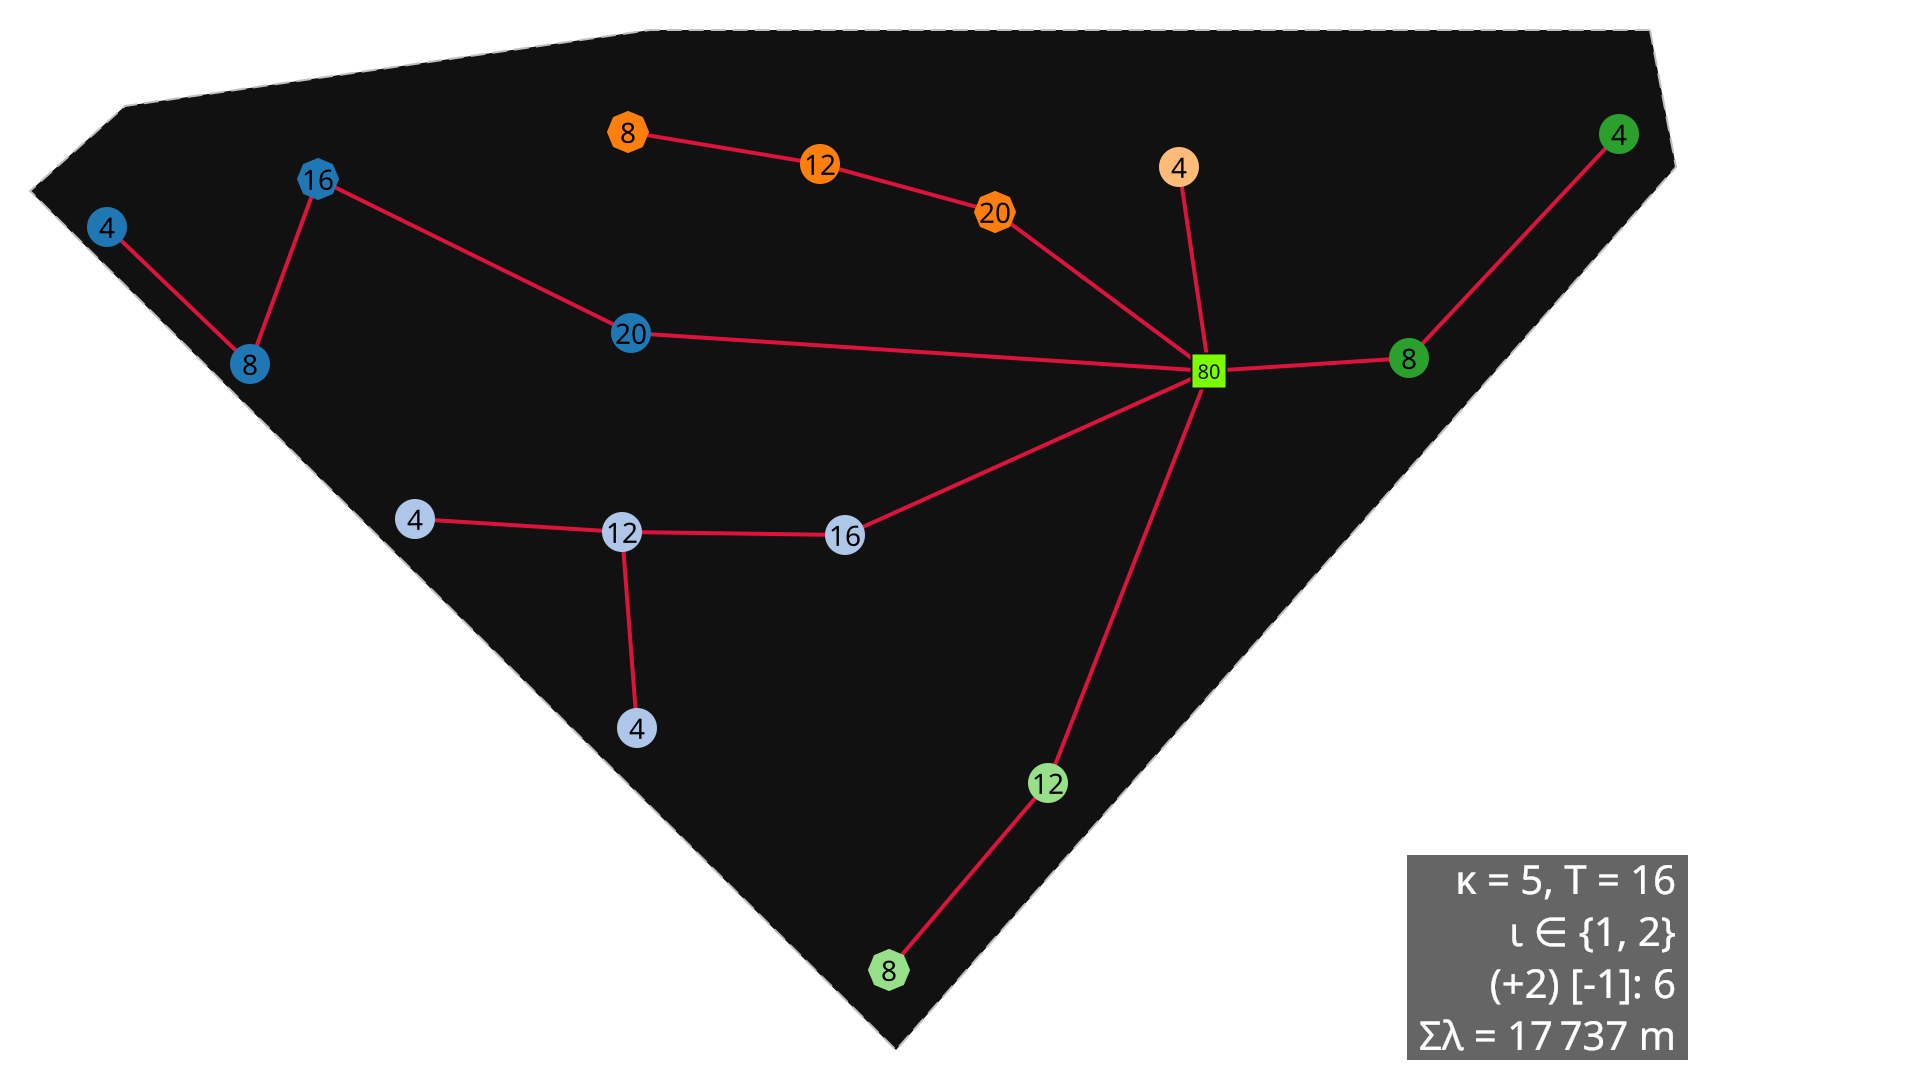

In [11]:
svgplot(G, node_tag='load_nominal')

### Derive inflow from nominal ratings and a cable budget

For ratings without an obvious small common unit, [quantize_for_capacity()](../autoapi/optiwindnet/loads/index.rst#optiwindnet.loads.quantize_for_capacity) returns a mapping from each distinct power to integer inflow, an exact rational unit, and one integer capacity. Only distinct ratings matter, not the number of turbines of each rating.

The tolerance bounds `abs(inflow * unit - power) / power` for each turbine. The helper also preserves which turbine combinations fit the given capacity; rounding ratings independently does not provide that guarantee. Zero tolerance preserves declared powers exactly, but can require much larger integers.

Use a second copy of the location for twelve 5 MW turbines and four 6.35 MW turbines. Compare a 16 MW routing budget with a 20 MW budget, and compare the default tolerance with zero. These are independent quantizations, not a simultaneous conversion of two cable types.

In [12]:
declared = [
    Fraction('6.35') if t in large_turbines else Fraction(5)
    for t in range(L.graph['T'])
]
L_mixed = locations.albatros.copy()
L_mixed.graph['name'] = 'Albatros geometry: illustrative 5 and 6.35 MW turbines'
set_turbine_powers(L_mixed, declared, power_unit='MW')
P_mixed, A_mixed = make_planar_embedding(L_mixed)

In [13]:
powers_set = A_mixed.graph['powers_set']
rows = []
for budget, tolerance in [(16, 0.01), (20, 0.01), (20, 0)]:
    inflow_by_power, unit, integer_capacity = quantize_for_capacity(
        powers_set, budget, power_rtol=tolerance
    )
    for power, inflow in inflow_by_power.items():
        assert abs(inflow * unit - power) / power <= Fraction(str(tolerance))
    rows.append(
        (
            budget,
            tolerance,
            str(unit),
            *(inflow_by_power[power] for power in powers_set),
            integer_capacity,
        )
    )
Table(
    rows,
    headers=[
        'budget (MW)',
        'rtol',
        'MW per inflow',
        *(f'inflow of {float(power):g} MW' for power in powers_set),
        'capacity (inflow)',
    ],
)

budget (MW),rtol,MW per inflow,inflow of 5 MW,inflow of 6.35 MW,capacity (inflow)
16,0.01,29/23,4,5,12
20,0.01,17/24,7,9,28
20,0,1/20,100,127,400


In [14]:
A_solve, integer_capacity, attrs = quantized(
    A_mixed, capacity_nominal=20, power_rtol=0.01
)
assert A_solve is not A_mixed
assert A_solve.graph['power_quantization_inexact']
assert 'power_per_inflow' not in A_mixed.graph
assert all('inflow' not in A_mixed.nodes[t] for t in range(A_mixed.graph['T']))
attrs

{'power_per_inflow': Fraction(17, 24),
 'capacity_nominal': Fraction(20, 1),
 'power_rtol': 0.01}

[quantized()](../autoapi/optiwindnet/loads/index.rst#optiwindnet.loads.quantized) exposes the copy and metadata that producers prepare internally. Pass the original **A** and a nominal capacity to the producer; there is no need to prequantize it or rebuild its mesh for each budget or tolerance.

### Solve and assign nominal cable types

Solve this alternative at 20 MW and the default tolerance. Reuse the same declaration for an exact setup to verify that its integer demands differ while **A** remains unchanged. Warm starts supplied to `set_problem()` are reloaded with the target solve's inflows if their quantization differs.

The largest cable defines the routing budget. `assign_cables()` compares each edge's declared downstream power with nominal cable capacities when the solution carries `capacity_nominal`; do not pass converted integer capacities in that case.

In [15]:
mixed_solver = solver_factory('ortools.cp_sat')
mixed_solver.set_problem(
    P_mixed, A_mixed, model_options=model_options, capacity_nominal=20, power_rtol=0.01
)
mixed_solver.solve(time_limit=30, mip_gap=0.01, options={'random_seed': 1234567})
S_mixed, G_mixed = mixed_solver.get_solution()

In [16]:
exact_solver = solver_factory('ortools.cp_sat')
exact_solver.set_problem(
    P_mixed, A_mixed, model_options=model_options, capacity_nominal=20, power_rtol=0
)
assert terminal_inflow(exact_solver.A) != terminal_inflow(mixed_solver.A)
assert all('inflow' not in A_mixed.nodes[t] for t in range(A_mixed.graph['T']))

In [17]:
cables_MW = [(16, 1.0), (20, 1.3)]
assign_cables(G_mixed, cables_MW)
for _, _, data in G_mixed.edges(data=True):
    assert data['load_nominal'] <= cables_MW[data['cable']][0]

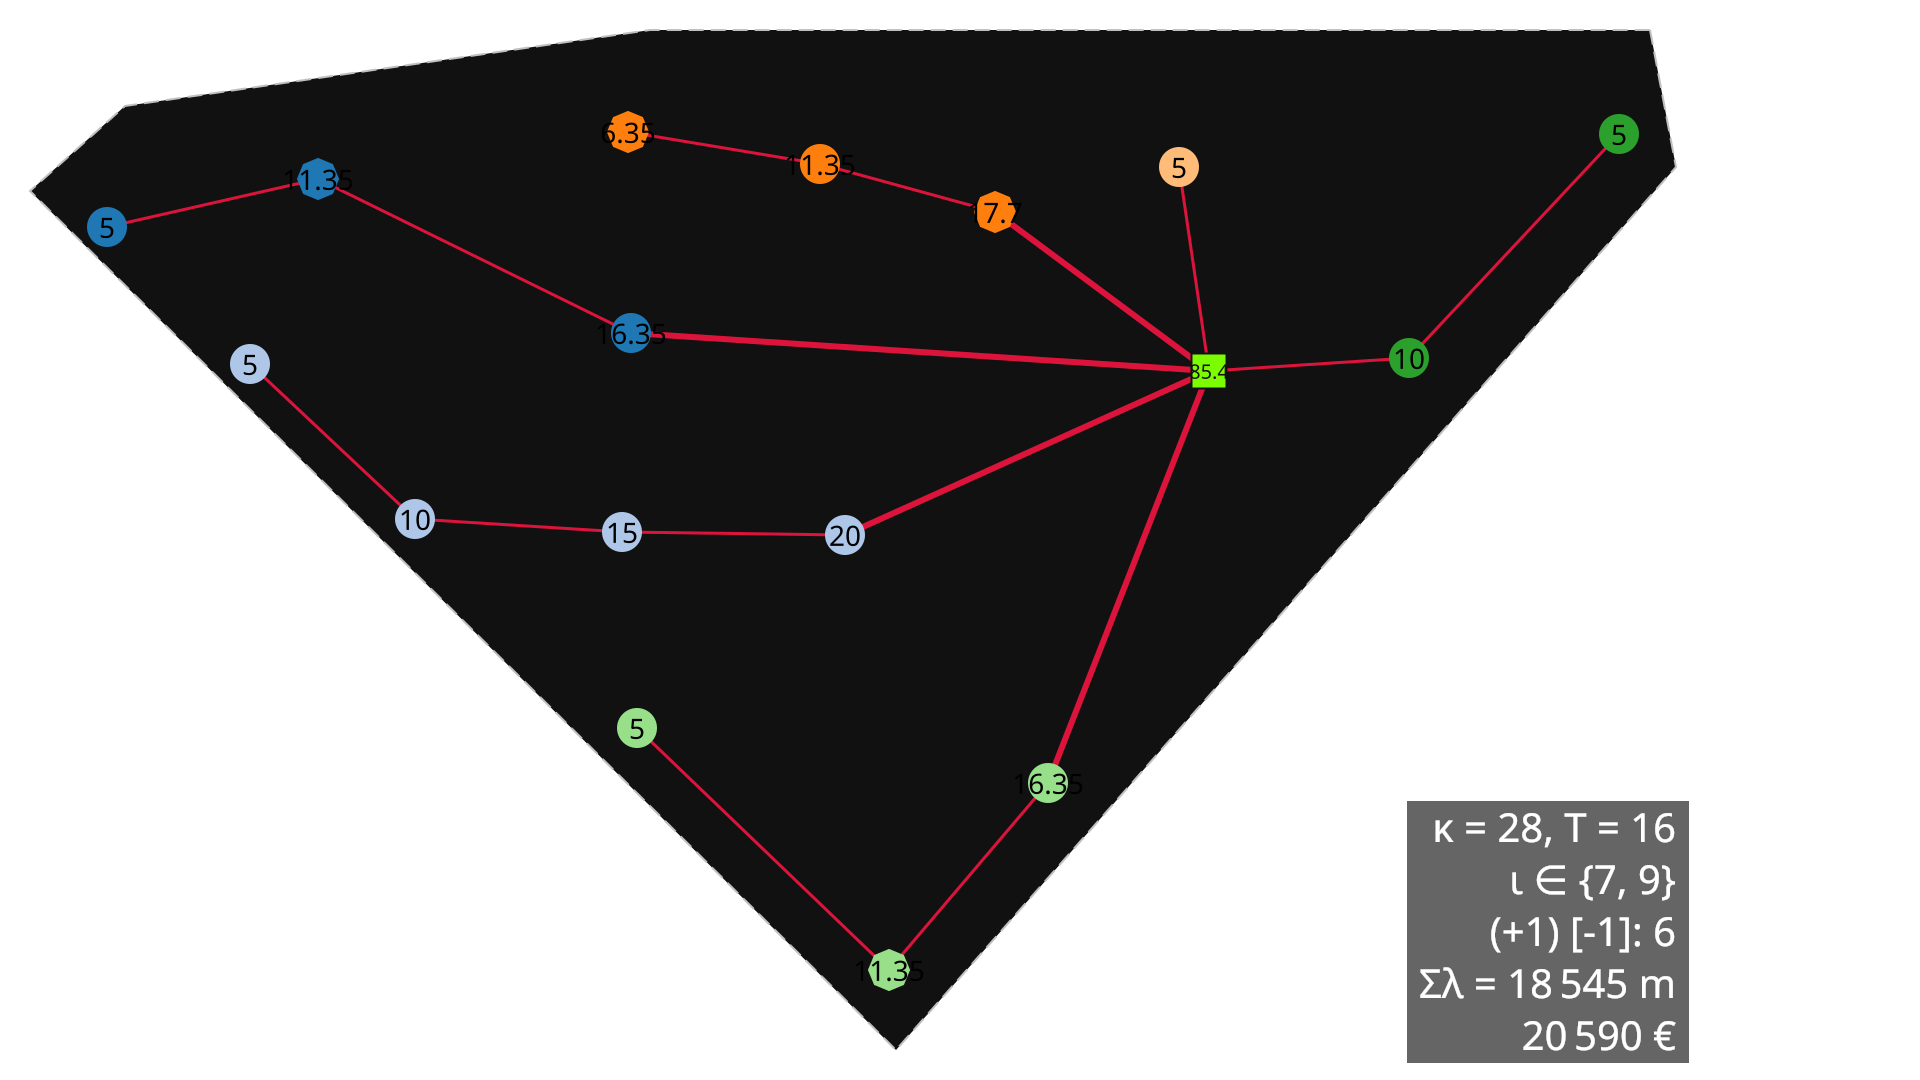

In [18]:
svgplot(G_mixed, node_tag='load_nominal')

### Compare integer, represented and nominal loads

With inexact quantization, integer load times `power_per_inflow` is an approximation. `calcload(G, nominal=True)` instead sums declared ratings, preserving the integer routing loads. Nominal plotting and cable assignment request these loads on demand. Compare feeder values and check that only the declared nominal loads recover the site's exact total.

In [19]:
integer_loads = {(u, v): d['load'] for u, v, d in G_mixed.edges(data=True)}
calcload(G_mixed, nominal=True)
assert integer_loads == {(u, v): d['load'] for u, v, d in G_mixed.edges(data=True)}
unit = G_mixed.graph['power_per_inflow']
assert G_mixed.graph['power_quantization_inexact']
feeders = [
    (t, G_mixed[root][t])
    for root in range(-G_mixed.graph['R'], 0)
    for t in G_mixed.neighbors(root)
]
represented_total = sum(data['load'] * unit for _, data in feeders)
nominal_total = sum(data['load_nominal'] for _, data in feeders)
assert nominal_total == sum(declared)
assert represented_total != nominal_total
Table(
    [
        (
            t,
            data['load'],
            round(float(data['load'] * unit), 4),
            float(data['load_nominal']),
        )
        for t, data in feeders
    ]
    + [
        (
            'total',
            sum(data['load'] for _, data in feeders),
            round(float(represented_total), 4),
            float(nominal_total),
        )
    ],
    headers=['feeder node', 'integer load', 'represented MW', 'declared MW'],
)

feeder node,integer load,represented MW,declared MW
11,7,4.9583,5.0
14,23,16.2917,16.35
10,25,17.7083,17.7
13,14,9.9167,10.0
9,28,19.8333,20.0
6,23,16.2917,16.35
total,120,85.0,85.4


### Reconstruct a topology from terse links

A terse encoding carries links, not inflows or power declarations. `to_topology()` quantizes the supplied site's ratings with the requested budget and tolerance, just as a producer does. [G_from_S()](../autoapi/optiwindnet/converting/index.rst#optiwindnet.converting.G_from_S) then combines the recovered quantization with the nominal declaration. This example checks topology and loads before any detour routing.

In [20]:
encoding = terse_links_from_S(S_mixed)
S_restored = encoding.to_topology(A_mixed, capacity_nominal=20, power_rtol=0.01)
assert terminal_inflow(S_restored) == terminal_inflow(S_mixed)
assert S_restored.graph['power_per_inflow'] == S_mixed.graph['power_per_inflow']
assert {frozenset(edge) for edge in S_restored.edges} == {
    frozenset(edge) for edge in S_mixed.edges
}
for u, v, data in S_mixed.edges(data=True):
    assert S_restored[u][v]['load'] == data['load']

In [21]:
G_restored = G_from_S(S_restored, A_mixed)
calcload(G_restored, nominal=True)
restored_total = sum(
    G_restored.nodes[root]['load_nominal'] for root in range(-G_restored.graph['R'], 0)
)
assert restored_total == nominal_total
{'restored_declared_generation_MW': float(restored_total)}

{'restored_declared_generation_MW': 85.4}

### Supported producers and persistence

| Producer or operation | Nonunit-inflow support |
| --- | --- |
| [solver_factory()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.solver_factory) MILP backends | Radial and branched models; `'unlimited'`, `'exactly'`, or `'specified'` feeder limits. |
| `hgs_cvrp()` and `lkh3()` | Unbalanced, single-substation radial solves; integer inflow becomes customer demand. |
| `constructor()` | Unsupported: its subtree construction counts turbines. |
| Ringed models; MILP `'minimum'` / `'min_plus*'` feeder limits | Unsupported: their partition/count assumptions do not hold for mixed inflows. |
| Routeset database storage | Refused for nonunit inflow or a `powers_set` declaration. |

The producers accept `capacity_nominal` and `power_rtol` just as `Solver.set_problem()` does. Router restrictions concern nonunit inflow: unequal ratings can sometimes quantize to unitary inflow under a loose tolerance. Database storage still refuses such unequal-power routesets; equal-power routesets retain their power attributes in storage.

OWN YAML and OSM importers declare nominal ratings on the location, ready for these producers; see [input formats](../reference/input_formats.md#supported-formats). Preserve that declaration, the capacity and the tolerance alongside a terse encoding to reproduce its loads.